# Discretization Trade-off

### K-Selection 
- **Static K=32** 
- **Static K=64** 
- **Static K=128** 
- **Theoretical K** $K^* = \lceil C \cdot N^{1/5} \rceil$ 
- **Heuristic K** (sweep 2…256, 1% early-stop) 

### Timing 
Each cell records **two independent timers**:
- `t_spacing_ms`: time to compute the discrete arrays (geomspace+digitize **or** DP fit+apply). This is the cost that differs between spacing algorithms.
- `t_lp_ms`: time to solve the discrete LP. Same oracle for all cells; reported for completeness.

## 0. Imports & Configuration

In [7]:
import sys, os, time, warnings
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.dirname(os.getcwd()))
sys.path.insert(0, 'src')

import src.discretizer_simulator as discretizer_simulator
importlib.reload(discretizer_simulator)
from src.discretizer_simulator import (
    Discretizer,
    SimulatorDiscretizer,
    generate_synthetic_jobs,
)

# ── Dataset ──────────────────────────────────────────────────────────────────
data_path = os.path.join('..', 'data', 'processed', 'batch_may2019_30k.csv')
df_raw = pd.read_csv(data_path)
df_raw = df_raw.rename(columns={
    'q_j':       'priority',
    'C_elec':    'c_elec',
    'C_carbon':  'c_carbon',
    'D (hours)': 'duration',
})

# ── Filter to positive-reward jobs  ──────
V_COL, PHI_COL = 'v_rate', 'phi_rate'
LAMBDAS = (1/3, 1/3, 1/3)
df = Discretizer.enforce_positive_reward(df_raw, V_COL, PHI_COL, LAMBDAS).copy()
print(f'Jobs after GIR filter: {len(df):,}  (dropped {len(df_raw)-len(df):,})')

# ── Fluid budget (same rho=0.60) ───────────────────────────────
def compute_fluid_capacities(df, load_factor=0.60):
    vol_cpu = df['A_cpu'] * df['duration']
    vol_ram = df['A_ram'] * df['duration']
    print(f"Total Offered CPU Volume: {vol_cpu.sum():.2f} core-hours | Scaled Capacity: {vol_cpu.sum() * load_factor:.2f} core-hours")
    print(f"Total Offered RAM Volume: {vol_ram.sum():.2f} unit-hours | Scaled Capacity: {vol_ram.sum() * load_factor:.2f} unit-hours")
    
    return {'b_cpu': vol_cpu.sum() * load_factor,
            'b_ram': vol_ram.sum() * load_factor}

bounds           = compute_fluid_capacities(df, load_factor=0.60)
CLUSTER_CAPACITY = {'cpu': bounds['b_cpu'], 'ram': bounds['b_ram']}
HORIZON          = 744.0   # hours (31-day month)

# ── Shared simulator ──────────────────────────────────────────────────────────
sd = SimulatorDiscretizer(
    K_bins=32, capacity=CLUSTER_CAPACITY, horizon=HORIZON, lambdas=LAMBDAS
)

# ── Plot style ────────────────────────────────────────────────────────────────
COLORS_GEO = '#DD8452'   # orange — Geometric
COLORS_DP  = '#55A868'   # green  — DP Grid
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print('Configuration OK')
print(f'Fluid budget → CPU: {CLUSTER_CAPACITY["cpu"]:,.0f} core-hours | '
      f'RAM: {CLUSTER_CAPACITY["ram"]:,.0f} unit-hours')

Jobs after GIR filter: 26,792  (dropped 2,888)
Total Offered CPU Volume: 1487304.38 core-hours | Scaled Capacity: 892382.63 core-hours
Total Offered RAM Volume: 1438287.00 unit-hours | Scaled Capacity: 862972.20 unit-hours
Configuration OK
Fluid budget → CPU: 892,383 core-hours | RAM: 862,972 unit-hours


In [8]:
# ── Experiment configuration ─────────────────────────────────────────────────
PHASE_SIZE         = 50
STATIC_KS          = [32, 64, 128]
K_HEURISTIC_MAX    = 256
THRESHOLD_PCT      = 0.1    # early-stop: marginal improvement < 0.1%
N_PHASES           = None   # None = full dataset; set e.g. 100 for quick preview

print(f'Running 2×5 matrix: phase_size={PHASE_SIZE}, static_Ks={STATIC_KS}, '
      f'heuristic_max={K_HEURISTIC_MAX}, n_phases={N_PHASES or "all"}')

t_wall = time.perf_counter()
matrix_df = sd.run_2x3_matrix_test(
    df,
    v_col               = V_COL,
    phi_col             = PHI_COL,
    phase_size          = PHASE_SIZE,
    static_ks           = STATIC_KS,
    k_heuristic_max     = K_HEURISTIC_MAX,
    k_search_threshold_pct = THRESHOLD_PCT,
    C                   = None,    # auto-calibrate in Phase 0
    lambda_1            = 1/3,
    lambda_2            = 1/3,
    n_phases            = N_PHASES,
    seed                = 42,
    verbose             = True,
)

print(f'\nTotal wall time: {time.perf_counter() - t_wall:.1f}s')
print(f'Phases completed: {len(matrix_df)}')
matrix_df.to_csv('matrix_results.csv', index=False)
print('Saved → matrix_results.csv')

Running 2×5 matrix: phase_size=50, static_Ks=[32, 64, 128], heuristic_max=256, n_phases=all

  Phase-0 calibration (50/50 train/test split) …
  [Phase-0 Calibration]  N=50  N^{1/5}=2.187  K*_empirical=12  →  C = 5.4877

  2×5 DISCRETIZATION MATRIX — phase_size=50  K_static=[32, 64, 128]  K_heuristic_max=256
  Theoretical K formula: K* = 5.4877 · N^(1/5)
  Early-stop threshold: 1.0% marginal improvement

  Phase    1  N=50  Fluid UB=319.0446  t_cont_LP=2.7ms
  Strategy                      Loss%    GIR   t_spacing      t_lp      K
  ----------------------------------------------------------------------
  Geo Static K=32              14.77%      1      0.362ms      2.1ms     32
  DP Static K=32               29.81%      1     24.250ms      1.9ms     32
  Geo Static K=64               9.47%      0      0.359ms      2.0ms     64
  DP Static K=64               29.73%      0      0.163ms      1.7ms     64
  Geo Static K=128              4.16%      0      0.889ms      2.3ms    128
  DP Static

## 2. Aggregate Summary Table

The primary thesis table: **Total Grid Loss** (absolute and % of cumulative Fluid Upper Bound reward) and **Mean Spacing Time** per cell across all phases.

In [9]:
total_ub = matrix_df['Fluid_Upper_Bound_Reward'].sum()

# Build the summary table programmatically
report_specs = [
    ('Geometric', 'K=32',       'Geo_K32'),
    ('Geometric', 'K=64',       'Geo_K64'),
    ('Geometric', 'K=128',      'Geo_K128'),
    ('Geometric', 'Heuristic',  'Geo_Heuristic'),
    ('DP Grid',   'K=32',       'DP_K32'),
    ('DP Grid',   'K=64',       'DP_K64'),
    ('DP Grid',   'K=128',      'DP_K128'),
    ('DP Grid',   'Theoretical','DP_Theo'),
    ('DP Grid',   'Heuristic',  'DP_Heuristic'),
]

rows = []
for spacing, strategy, pf in report_specs:
    lc  = f'{pf}_Loss_abs'
    sc  = f'{pf}_t_spacing_ms'
    lpc = f'{pf}_t_lp_ms'
    if lc not in matrix_df.columns:
        continue
    total_loss   = matrix_df[lc].sum()
    overall_pct  = total_loss / total_ub * 100 if total_ub > 0 else 0.0
    mean_loss_pct = matrix_df[f'{pf}_Loss_pct'].mean()
    mean_spacing = matrix_df[sc].mean()
    mean_lp      = matrix_df[lpc].mean()
    total_gir    = matrix_df[f'{pf}_GIR'].sum()

    # For heuristic strategies, also report mean K chosen
    if strategy == 'Heuristic':
        k_col = 'K_Geo_Heuristic' if spacing == 'Geometric' else 'K_DP_Heuristic'
        mean_k = matrix_df[k_col].mean()
        k_str  = f'{mean_k:.1f} (mean)'
    elif strategy == 'Theoretical':
        mean_k = matrix_df['K_Theo'].mean()
        k_str  = f'{mean_k:.1f} (mean)'
    else:
        k_str = strategy.replace('K=', '')

    rows.append({
        'Spacing':           spacing,
        'Strategy':          strategy,
        'K':                 k_str,
        'Total Loss':        round(total_loss, 2),
        'Overall Loss %':    round(overall_pct, 3),
        'Mean Loss % / phase': round(mean_loss_pct, 3),
        'Mean Spacing (ms)': round(mean_spacing, 4),
        'Mean LP (ms)':      round(mean_lp, 2),
        'Total GIR':         int(total_gir),
    })

summary_tbl = pd.DataFrame(rows).set_index(['Spacing', 'Strategy'])

# Speedup column: DP spacing time / Geo spacing time for same strategy
geo_times = {r['Strategy']: r['Mean Spacing (ms)']
             for r in rows if r['Spacing'] == 'Geometric'}
dp_times  = {r['Strategy']: r['Mean Spacing (ms)']
             for r in rows if r['Spacing'] == 'DP Grid'}

print(f'\nTotal Fluid Upper Bound Reward across {len(matrix_df)} phases: {total_ub:.2f}')
print(f'\n{"="*90}')
print('  AGGREGATE COST-BENEFIT SUMMARY')
print(f'{"="*90}')
display(
    summary_tbl.style
    .format({'Overall Loss %':     '{:.3f}',
             'Mean Loss % / phase':'{:.3f}',
             'Mean Spacing (ms)':  '{:.4f}',
             'Mean LP (ms)':       '{:.2f}',
             'Total Loss':         '{:.2f}'})
    .background_gradient(subset=['Overall Loss %'], cmap='RdYlGn_r')
    .background_gradient(subset=['Mean Spacing (ms)'], cmap='RdYlGn_r')
    .set_caption(f'2×5 Discretization Matrix — {len(matrix_df)} phases × {PHASE_SIZE} jobs/phase')
)

# Speedup ratios
print('\nSpacing speedup  (DP spacing time / Geo spacing time, same strategy):')
for strat in geo_times:
    if strat in dp_times:
        ratio = dp_times[strat] / geo_times[strat] if geo_times[strat] > 0 else float('inf')
        print(f'  {strat:<14s}: DP takes {ratio:6.1f}× longer than Geometric')


Total Fluid Upper Bound Reward across 10 phases: 304119.51

  AGGREGATE COST-BENEFIT SUMMARY



Spacing speedup  (DP spacing time / Geo spacing time, same strategy):
  K=32          : DP takes 17484.3× longer than Geometric
  K=64          : DP takes 38155.2× longer than Geometric
  K=128         : DP takes 81593.7× longer than Geometric
  Heuristic     : DP takes 16607.6× longer than Geometric


## 3. Main Result: Performance vs. Spacing Time (Scatter)

The primary thesis figure. Each point is one cell of the 2×5 matrix.
The **bottom-left quadrant** is the Pareto frontier: low loss *and* fast computation.
The ideal algorithm sits as far bottom-left as possible.

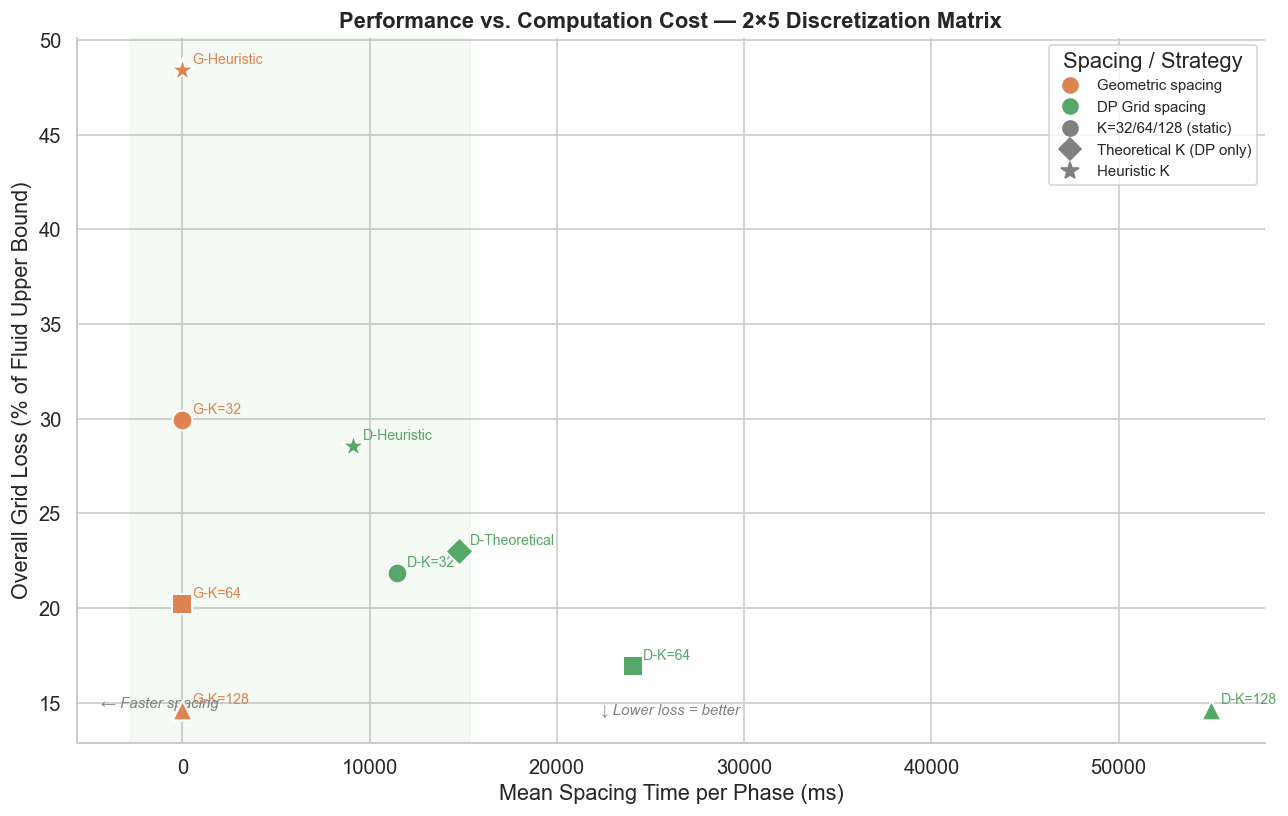

Saved → matrix_scatter.pdf


In [10]:
fig, ax = plt.subplots(figsize=(11, 7))

markers = {'K=32': 'o', 'K=64': 's', 'K=128': '^', 'Theoretical': 'D', 'Heuristic': '*'}
colors  = {'Geometric': COLORS_GEO, 'DP Grid': COLORS_DP}

for _, row in pd.DataFrame(rows).iterrows():
    ax.scatter(
        row['Mean Spacing (ms)'],
        row['Overall Loss %'],
        s       = 220 if row['Strategy'] == 'Heuristic' else 140,
        marker  = markers.get(row['Strategy'], 'o'),
        color   = colors[row['Spacing']],
        edgecolors = 'white',
        linewidths = 1.2,
        zorder  = 5,
        label   = f"{row['Spacing']} {row['Strategy']}",
    )
    ax.annotate(
        f"{row['Spacing'][0]}-{row['Strategy']}",
        (row['Mean Spacing (ms)'], row['Overall Loss %']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=8.5, color=colors[row['Spacing']],
    )

# Pareto-frontier annotation
ax.axvspan(ax.get_xlim()[0], ax.get_xlim()[0] + (ax.get_xlim()[1]-ax.get_xlim()[0])*0.3,
           alpha=0.04, color='green')
ax.text(0.02, 0.05, '← Faster spacing',
        transform=ax.transAxes, fontsize=9, color='grey', style='italic')
ax.text(0.5, 0.04, '↓ Lower loss = better',
        transform=ax.transAxes, fontsize=9, color='grey', style='italic', ha='center')

# Legend — deduplicate by spacing type
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS_GEO,
           markersize=11, label='Geometric spacing'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS_DP,
           markersize=11, label='DP Grid spacing'),
    Line2D([0],[0], marker='o', color='grey', linestyle='None',
           markersize=9, label='K=32/64/128 (static)'),
    Line2D([0],[0], marker='D', color='grey', linestyle='None',
           markersize=9, label='Theoretical K (DP only)'),
    Line2D([0],[0], marker='*', color='grey', linestyle='None',
           markersize=11, label='Heuristic K'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
          title='Spacing / Strategy')

ax.set_xlabel('Mean Spacing Time per Phase (ms)', fontsize=13)
ax.set_ylabel('Overall Grid Loss (% of Fluid Upper Bound)', fontsize=13)
ax.set_title('Performance vs. Computation Cost — 2×5 Discretization Matrix',
             fontweight='bold')
plt.tight_layout()
plt.savefig('matrix_scatter.pdf', bbox_inches='tight')
plt.show()
print('Saved → matrix_scatter.pdf')

## 4. Loss Distribution Across Phases

Box-plots of per-phase Grid Loss (%) for each cell. This shows not just the mean but the spread — a method with low mean but high variance is less reliable for the online DP agent.

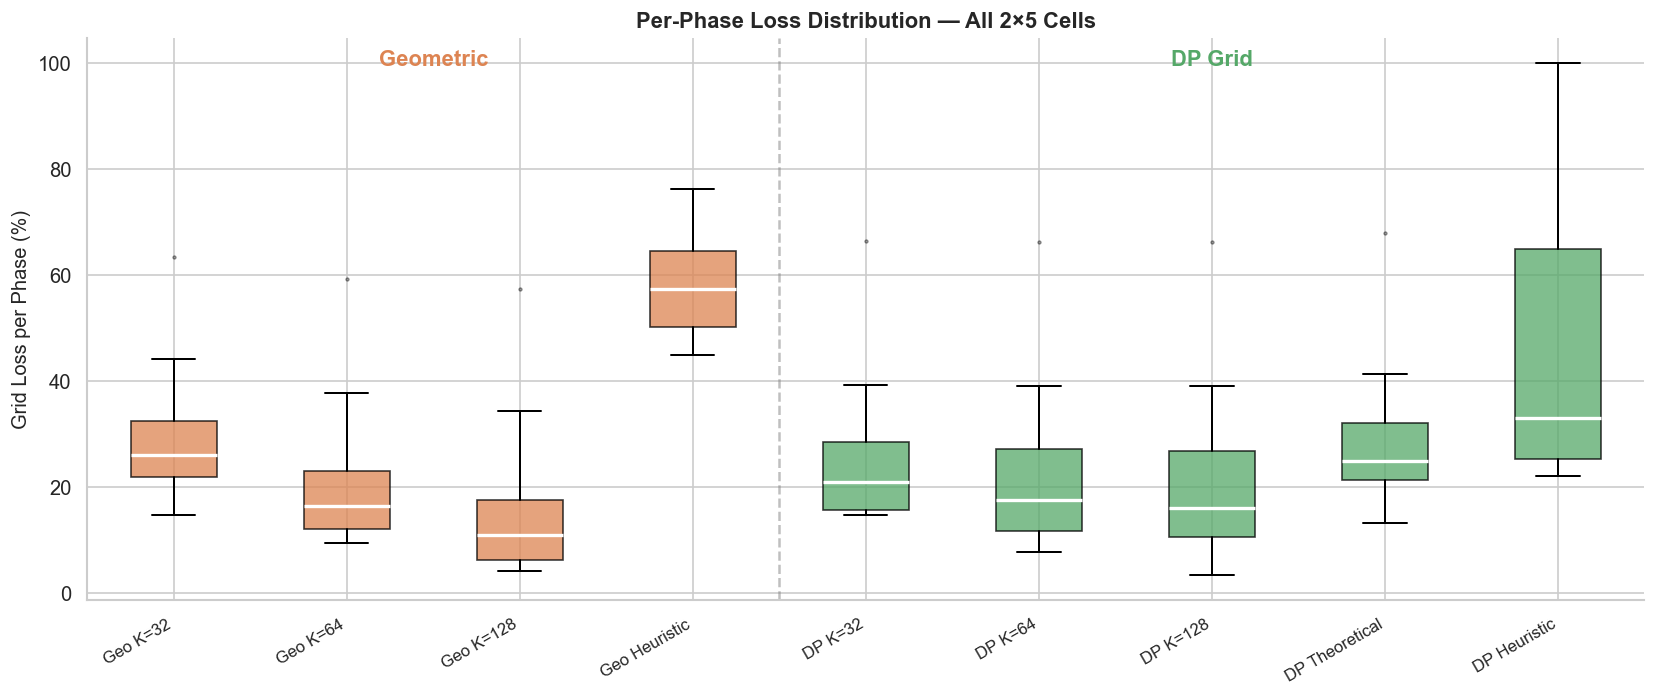

Saved → matrix_loss_boxplots.pdf


In [11]:
# Collect per-phase loss % for all cells
plot_specs = [
    ('Geo K=32',       'Geo_K32_Loss_pct',       COLORS_GEO, 'o'),
    ('Geo K=64',       'Geo_K64_Loss_pct',        COLORS_GEO, 's'),
    ('Geo K=128',      'Geo_K128_Loss_pct',       COLORS_GEO, '^'),
    ('Geo Heuristic',  'Geo_Heuristic_Loss_pct',  COLORS_GEO, '*'),
    ('DP K=32',        'DP_K32_Loss_pct',         COLORS_DP,  'o'),
    ('DP K=64',        'DP_K64_Loss_pct',         COLORS_DP,  's'),
    ('DP K=128',       'DP_K128_Loss_pct',        COLORS_DP,  '^'),
    ('DP Theoretical', 'DP_Theo_Loss_pct',        COLORS_DP,  'D'),
    ('DP Heuristic',   'DP_Heuristic_Loss_pct',   COLORS_DP,  '*'),
]
# Filter to columns that actually exist
plot_specs = [(lbl, col, clr, mk)
              for lbl, col, clr, mk in plot_specs
              if col in matrix_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))

data_list  = [matrix_df[col].values for _, col, _, _ in plot_specs]
labels     = [lbl for lbl, _, _, _ in plot_specs]
box_colors = [clr for _, _, clr, _ in plot_specs]

bp = ax.boxplot(data_list, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2.0),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=3, alpha=0.5))

for patch, col in zip(bp['boxes'], box_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Grid Loss per Phase (%)', fontsize=12)
ax.set_title('Per-Phase Loss Distribution — All 2×5 Cells', fontweight='bold')

# Vertical separator between Geometric and DP groups
geo_count = sum(1 for lbl, *_ in plot_specs if lbl.startswith('Geo'))
ax.axvline(geo_count + 0.5, color='grey', linestyle='--', alpha=0.5)
ax.text(geo_count * 0.5 + 0.5, ax.get_ylim()[1] * 0.95,
        'Geometric', ha='center', color=COLORS_GEO, fontweight='bold')
ax.text(geo_count + (len(plot_specs) - geo_count) * 0.5 + 0.5,
        ax.get_ylim()[1] * 0.95,
        'DP Grid', ha='center', color=COLORS_DP, fontweight='bold')

plt.tight_layout()
plt.savefig('matrix_loss_boxplots.pdf', bbox_inches='tight')
plt.show()
print('Saved → matrix_loss_boxplots.pdf')

## 5. Spacing Time Distribution Across Phases

The definitive timing comparison. Box-plots of `t_spacing_ms` per cell.
The LP solve time (`t_lp_ms`) is shown as a horizontal reference line — it is approximately equal for all cells and represents the irreducible cost floor.

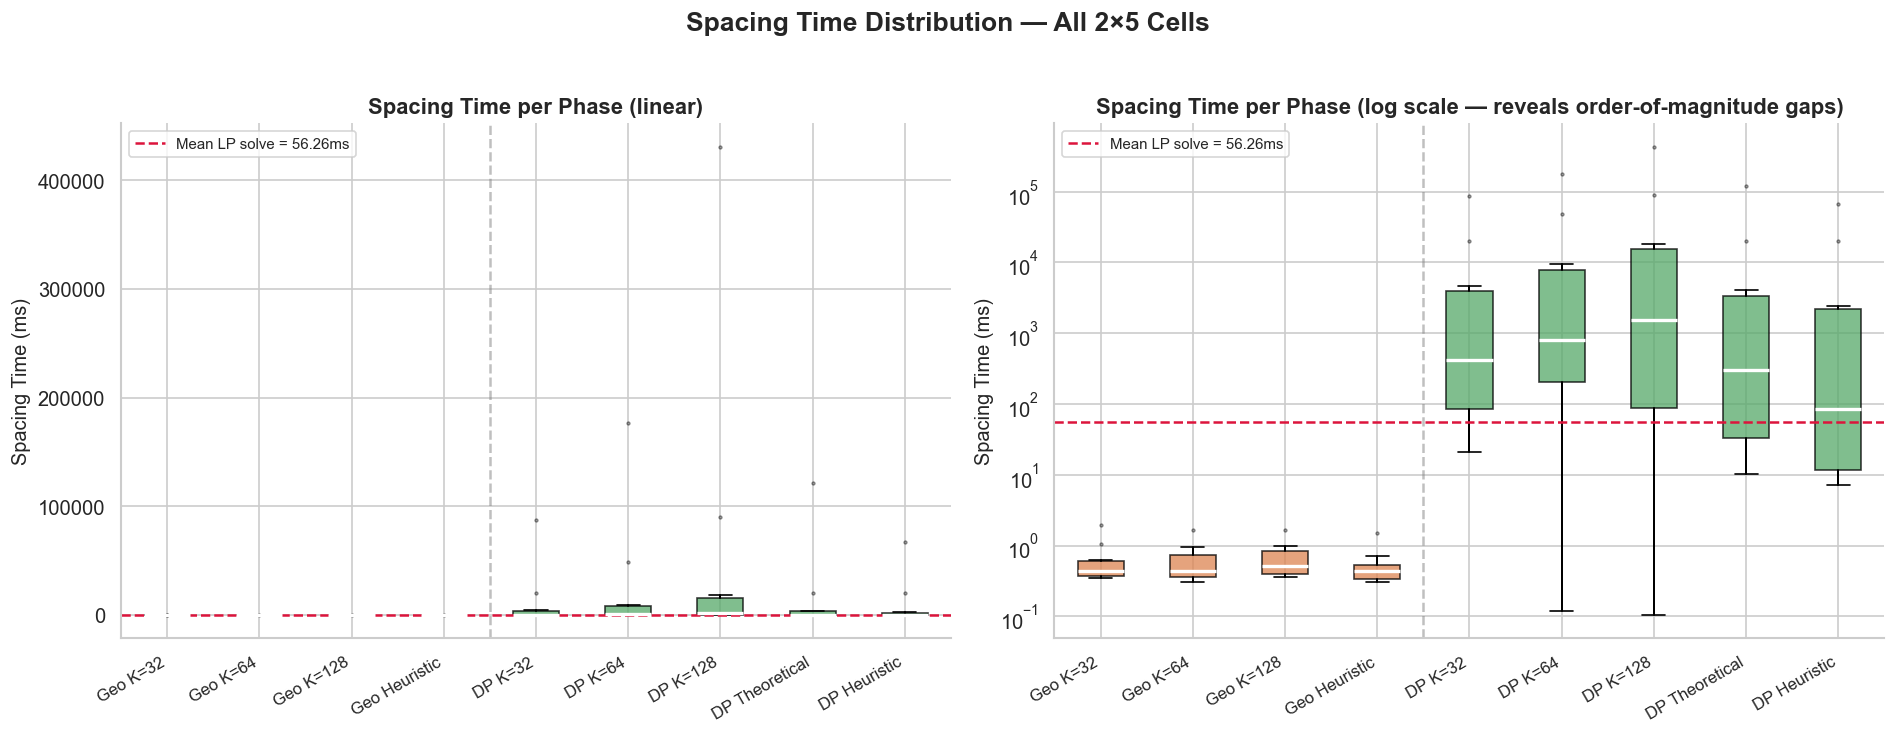

Saved → matrix_timing_boxplots.pdf


In [12]:
time_specs = [
    ('Geo K=32',       'Geo_K32_t_spacing_ms',       'Geo_K32_t_lp_ms',       COLORS_GEO),
    ('Geo K=64',       'Geo_K64_t_spacing_ms',        'Geo_K64_t_lp_ms',        COLORS_GEO),
    ('Geo K=128',      'Geo_K128_t_spacing_ms',       'Geo_K128_t_lp_ms',       COLORS_GEO),
    ('Geo Heuristic',  'Geo_Heuristic_t_spacing_ms',  'Geo_Heuristic_t_lp_ms',  COLORS_GEO),
    ('DP K=32',        'DP_K32_t_spacing_ms',         'DP_K32_t_lp_ms',         COLORS_DP),
    ('DP K=64',        'DP_K64_t_spacing_ms',         'DP_K64_t_lp_ms',         COLORS_DP),
    ('DP K=128',       'DP_K128_t_spacing_ms',        'DP_K128_t_lp_ms',        COLORS_DP),
    ('DP Theoretical', 'DP_Theo_t_spacing_ms',        'DP_Theo_t_lp_ms',        COLORS_DP),
    ('DP Heuristic',   'DP_Heuristic_t_spacing_ms',   'DP_Heuristic_t_lp_ms',   COLORS_DP),
]
time_specs = [(lbl, sc, lc, clr)
              for lbl, sc, lc, clr in time_specs
              if sc in matrix_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, log_scale, title_suffix in zip(
    axes, [False, True], ['(linear)', '(log scale — reveals order-of-magnitude gaps)']
):
    data_list  = [matrix_df[sc].values for _, sc, _, _ in time_specs]
    labels     = [lbl for lbl, *_ in time_specs]
    box_colors = [clr for _, _, _, clr in time_specs]

    bp = ax.boxplot(data_list, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.0),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='.', markersize=3, alpha=0.5))
    for patch, col in zip(bp['boxes'], box_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    # LP reference line (mean across all cells — approximately constant)
    mean_lp = np.mean([matrix_df[lc].mean() for _, _, lc, _ in time_specs])
    ax.axhline(mean_lp, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mean LP solve = {mean_lp:.2f}ms')

    if log_scale:
        ax.set_yscale('log')
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Spacing Time (ms)', fontsize=12)
    ax.set_title(f'Spacing Time per Phase {title_suffix}', fontweight='bold')
    ax.legend(fontsize=9)

    # Separator
    geo_count = sum(1 for lbl, *_ in time_specs if lbl.startswith('Geo'))
    ax.axvline(geo_count + 0.5, color='grey', linestyle='--', alpha=0.5)

plt.suptitle('Spacing Time Distribution — All 2×5 Cells', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrix_timing_boxplots.pdf', bbox_inches='tight')
plt.show()
print('Saved → matrix_timing_boxplots.pdf')

## 6. Heuristic K Selection Over Phases

Tracks the K chosen by the Geometric and DP heuristics at each phase.
A stable, low K is evidence that the 1% early-stop rule converges quickly and that
the heuristic is not artificially inflating K (which would waste computation time
without improving loss).

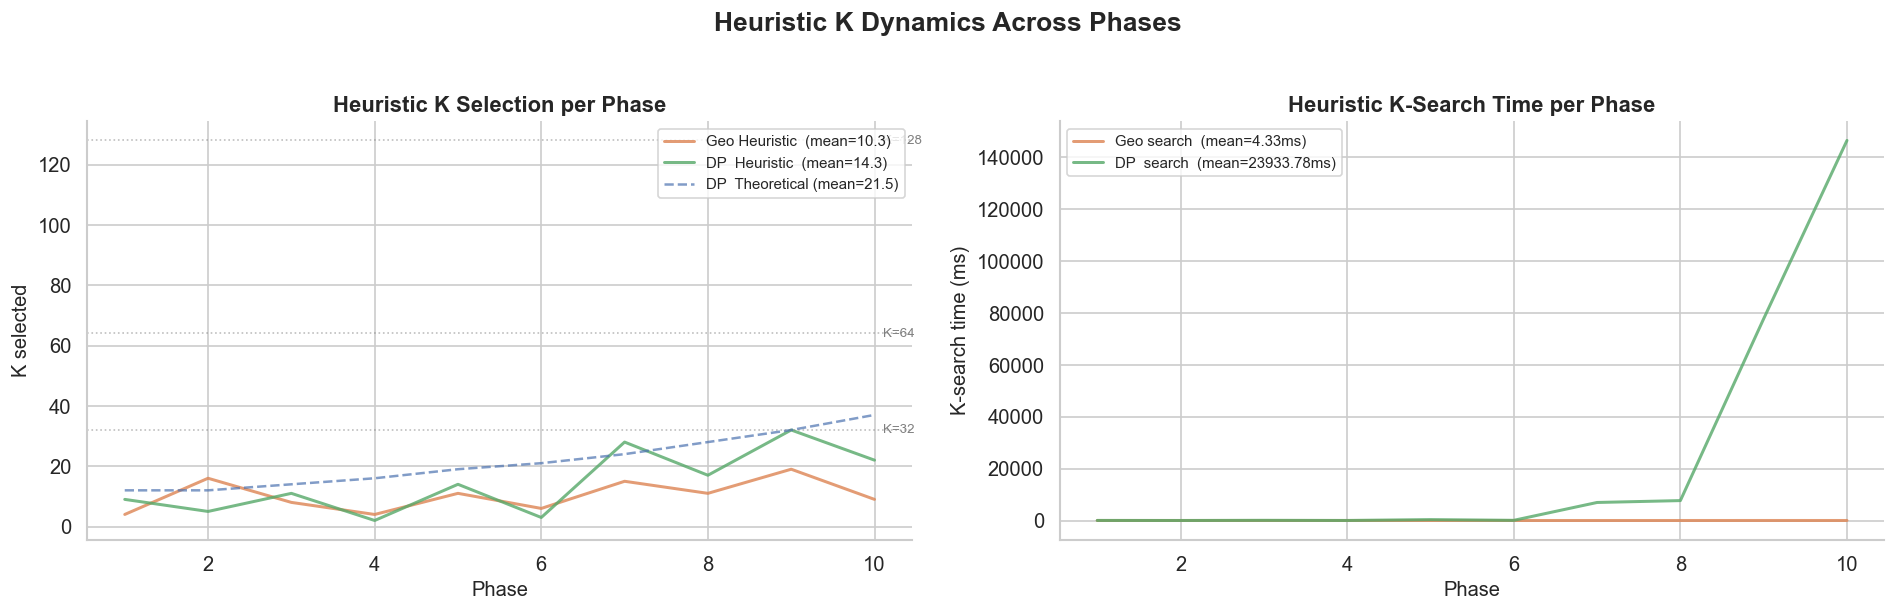

Saved → matrix_heuristic_k.pdf


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

phases = matrix_df['Phase'].values

# ── Left: K chosen per phase ───────────────────────────────────────────────
if 'K_Geo_Heuristic' in matrix_df.columns:
    axes[0].plot(phases, matrix_df['K_Geo_Heuristic'], '-', color=COLORS_GEO,
                 label=f'Geo Heuristic  (mean={matrix_df["K_Geo_Heuristic"].mean():.1f})',
                 linewidth=1.8, alpha=0.8)
if 'K_DP_Heuristic' in matrix_df.columns:
    axes[0].plot(phases, matrix_df['K_DP_Heuristic'], '-', color=COLORS_DP,
                 label=f'DP  Heuristic  (mean={matrix_df["K_DP_Heuristic"].mean():.1f})',
                 linewidth=1.8, alpha=0.8)
if 'K_Theo' in matrix_df.columns:
    axes[0].plot(phases, matrix_df['K_Theo'], '--', color='#4C72B0',
                 label=f'DP  Theoretical (mean={matrix_df["K_Theo"].mean():.1f})',
                 linewidth=1.5, alpha=0.7)

for k in STATIC_KS:
    axes[0].axhline(k, color='grey', linestyle=':', linewidth=1.0, alpha=0.5)
    axes[0].text(phases[-1] * 1.01, k, f'K={k}', fontsize=8, color='grey', va='center')

axes[0].set_xlabel('Phase', fontsize=12)
axes[0].set_ylabel('K selected', fontsize=12)
axes[0].set_title('Heuristic K Selection per Phase', fontweight='bold')
axes[0].legend(fontsize=9)

# ── Right: heuristic search time per phase ─────────────────────────────────
if 'Geo_Heuristic_t_search_ms' in matrix_df.columns:
    axes[1].plot(phases, matrix_df['Geo_Heuristic_t_search_ms'],
                 '-', color=COLORS_GEO,
                 label=f'Geo search  (mean={matrix_df["Geo_Heuristic_t_search_ms"].mean():.2f}ms)',
                 linewidth=1.8, alpha=0.8)
if 'DP_Heuristic_t_search_ms' in matrix_df.columns:
    axes[1].plot(phases, matrix_df['DP_Heuristic_t_search_ms'],
                 '-', color=COLORS_DP,
                 label=f'DP  search  (mean={matrix_df["DP_Heuristic_t_search_ms"].mean():.2f}ms)',
                 linewidth=1.8, alpha=0.8)

axes[1].set_xlabel('Phase', fontsize=12)
axes[1].set_ylabel('K-search time (ms)', fontsize=12)
axes[1].set_title('Heuristic K-Search Time per Phase', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Heuristic K Dynamics Across Phases', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrix_heuristic_k.pdf', bbox_inches='tight')
plt.show()
print('Saved → matrix_heuristic_k.pdf')

## 7. Speedup vs. Loss Penalty Table

The key thesis narrative table: for each Geometric vs. DP pair at the same K-strategy,
how much faster is Geometric and what is the loss penalty (or gain) of choosing it over DP?

In [14]:
comparable_pairs = [
    ('K=32',      'Geo_K32',       'DP_K32'),
    ('K=64',      'Geo_K64',       'DP_K64'),
    ('K=128',     'Geo_K128',      'DP_K128'),
    ('Heuristic', 'Geo_Heuristic', 'DP_Heuristic'),
]

pair_rows = []
for strategy, geo_pf, dp_pf in comparable_pairs:
    if f'{geo_pf}_Loss_abs' not in matrix_df.columns:
        continue
    geo_loss  = matrix_df[f'{geo_pf}_Loss_abs'].sum() / total_ub * 100
    dp_loss   = matrix_df[f'{dp_pf}_Loss_abs'].sum()  / total_ub * 100
    geo_sp    = matrix_df[f'{geo_pf}_t_spacing_ms'].mean()
    dp_sp     = matrix_df[f'{dp_pf}_t_spacing_ms'].mean()
    speedup   = dp_sp / geo_sp if geo_sp > 0 else float('inf')
    loss_diff = geo_loss - dp_loss   # positive = Geo is worse; negative = Geo is better

    pair_rows.append({
        'Strategy':                strategy,
        'Geo Loss %':              round(geo_loss, 3),
        'DP Loss %':               round(dp_loss, 3),
        'Loss Δ (Geo − DP)':      round(loss_diff, 3),
        'Geo Spacing (ms)':        round(geo_sp, 4),
        'DP Spacing (ms)':         round(dp_sp, 4),
        'Speedup (DP / Geo)':      round(speedup, 1),
    })

pair_tbl = pd.DataFrame(pair_rows).set_index('Strategy')

def color_loss_delta(val):
    try:
        v = float(val)
        if v <= 0:   return 'background-color:#1a7a4a; color:white; font-weight:bold'
        if v <= 2.0: return 'background-color:#c87f0a; color:white; font-weight:bold'
        return 'background-color:#b52b2b; color:white; font-weight:bold'
    except: return ''

def color_speedup(val):
    try:
        v = float(val)
        if v >= 50:  return 'background-color:#1a7a4a; color:white; font-weight:bold'
        if v >= 10:  return 'background-color:#c87f0a; color:white; font-weight:bold'
        return ''
    except: return ''

display(
    pair_tbl.style
    .format({
        'Geo Loss %':         '{:.3f}',
        'DP Loss %':          '{:.3f}',
        'Loss Δ (Geo − DP)': '{:.3f}',
        'Geo Spacing (ms)':   '{:.4f}',
        'DP Spacing (ms)':    '{:.4f}',
        'Speedup (DP / Geo)': '{:.1f}×',
    })
    .map(color_loss_delta, subset=['Loss Δ (Geo − DP)'])
    .map(color_speedup,    subset=['Speedup (DP / Geo)'])
    .set_caption(
        'Geometric vs. DP Grid — same K-strategy. '
        'Green speedup = Geo is ≥50× faster. '
        'Green loss Δ = Geo is as good or better than DP.'
    )
)

print('\nConclusion check:')
for _, r in pair_tbl.iterrows():
    verdict = ''
    if r['Speedup (DP / Geo)'] >= 10 and r['Loss Δ (Geo − DP)'] <= 2.0:
        verdict = '✅ Geometric dominates (≥10× faster, ≤2% extra loss)'
    elif r['Loss Δ (Geo − DP)'] > 5.0:
        verdict = '⚠️  DP wins on loss (gap > 5%)'
    else:
        verdict = '↔  Marginal — inspect per-phase plots'
    print(f'  {r.name:<14s}: {verdict}')

,Geo Loss %,DP Loss %,Loss Δ (Geo − DP),Geo Spacing (ms),DP Spacing (ms),Speedup (DP / Geo)
Strategy,,,,,,
K=32,29.917,21.850,8.066,0.6540,11434.7050,17485.4×
K=64,20.222,16.942,3.279,0.6302,24045.4102,38154.1×
K=128,14.587,14.583,0.004,0.6731,54920.7147,81596.3×
Heuristic,48.427,28.542,19.886,0.5471,9086.0073,16607.6×



Conclusion check:
  K=32          : ⚠️  DP wins on loss (gap > 5%)
  K=64          : ↔  Marginal — inspect per-phase plots
  K=128         : ✅ Geometric dominates (≥10× faster, ≤2% extra loss)
  Heuristic     : ⚠️  DP wins on loss (gap > 5%)


## 8. GIR Analysis Across Strategies

Total Grid-Induced Rejections (GIR) per cell. A high GIR count means discretization
is causing the LP to reject jobs that the continuous oracle would have accepted.
This is a fairness/welfare metric separate from profit loss.

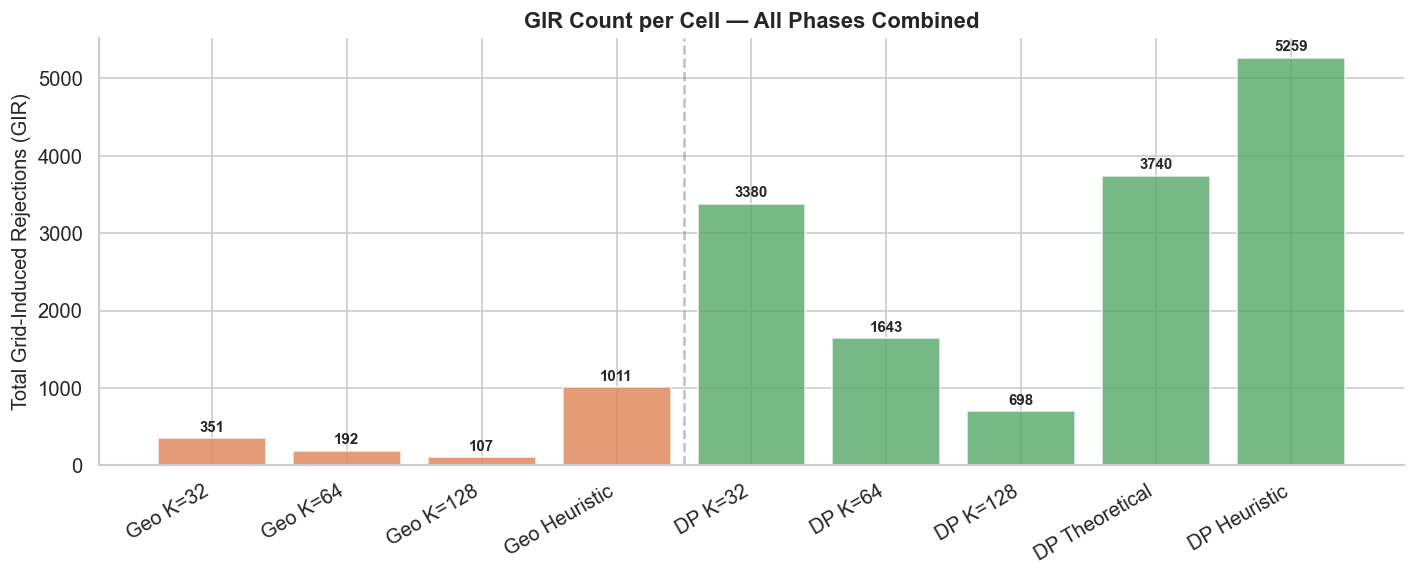

Saved → matrix_gir.pdf


In [15]:
gir_specs = [
    ('Geo K=32',       'Geo_K32_GIR',       COLORS_GEO),
    ('Geo K=64',       'Geo_K64_GIR',        COLORS_GEO),
    ('Geo K=128',      'Geo_K128_GIR',       COLORS_GEO),
    ('Geo Heuristic',  'Geo_Heuristic_GIR',  COLORS_GEO),
    ('DP K=32',        'DP_K32_GIR',         COLORS_DP),
    ('DP K=64',        'DP_K64_GIR',         COLORS_DP),
    ('DP K=128',       'DP_K128_GIR',        COLORS_DP),
    ('DP Theoretical', 'DP_Theo_GIR',        COLORS_DP),
    ('DP Heuristic',   'DP_Heuristic_GIR',   COLORS_DP),
]
gir_specs = [(lbl, col, clr) for lbl, col, clr in gir_specs
             if col in matrix_df.columns]

labels     = [lbl for lbl, *_ in gir_specs]
totals     = [matrix_df[col].sum() for _, col, _ in gir_specs]
bar_colors = [clr for _, _, clr in gir_specs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, totals, color=bar_colors, edgecolor='white', alpha=0.8)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(totals)*0.01,
            str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')

geo_count = sum(1 for lbl, *_ in gir_specs if lbl.startswith('Geo'))
ax.axvline(geo_count - 0.5, color='grey', linestyle='--', alpha=0.5)

ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Total Grid-Induced Rejections (GIR)', fontsize=12)
ax.set_title('GIR Count per Cell — All Phases Combined', fontweight='bold')
plt.tight_layout()
plt.savefig('matrix_gir.pdf', bbox_inches='tight')
plt.show()
print('Saved → matrix_gir.pdf')

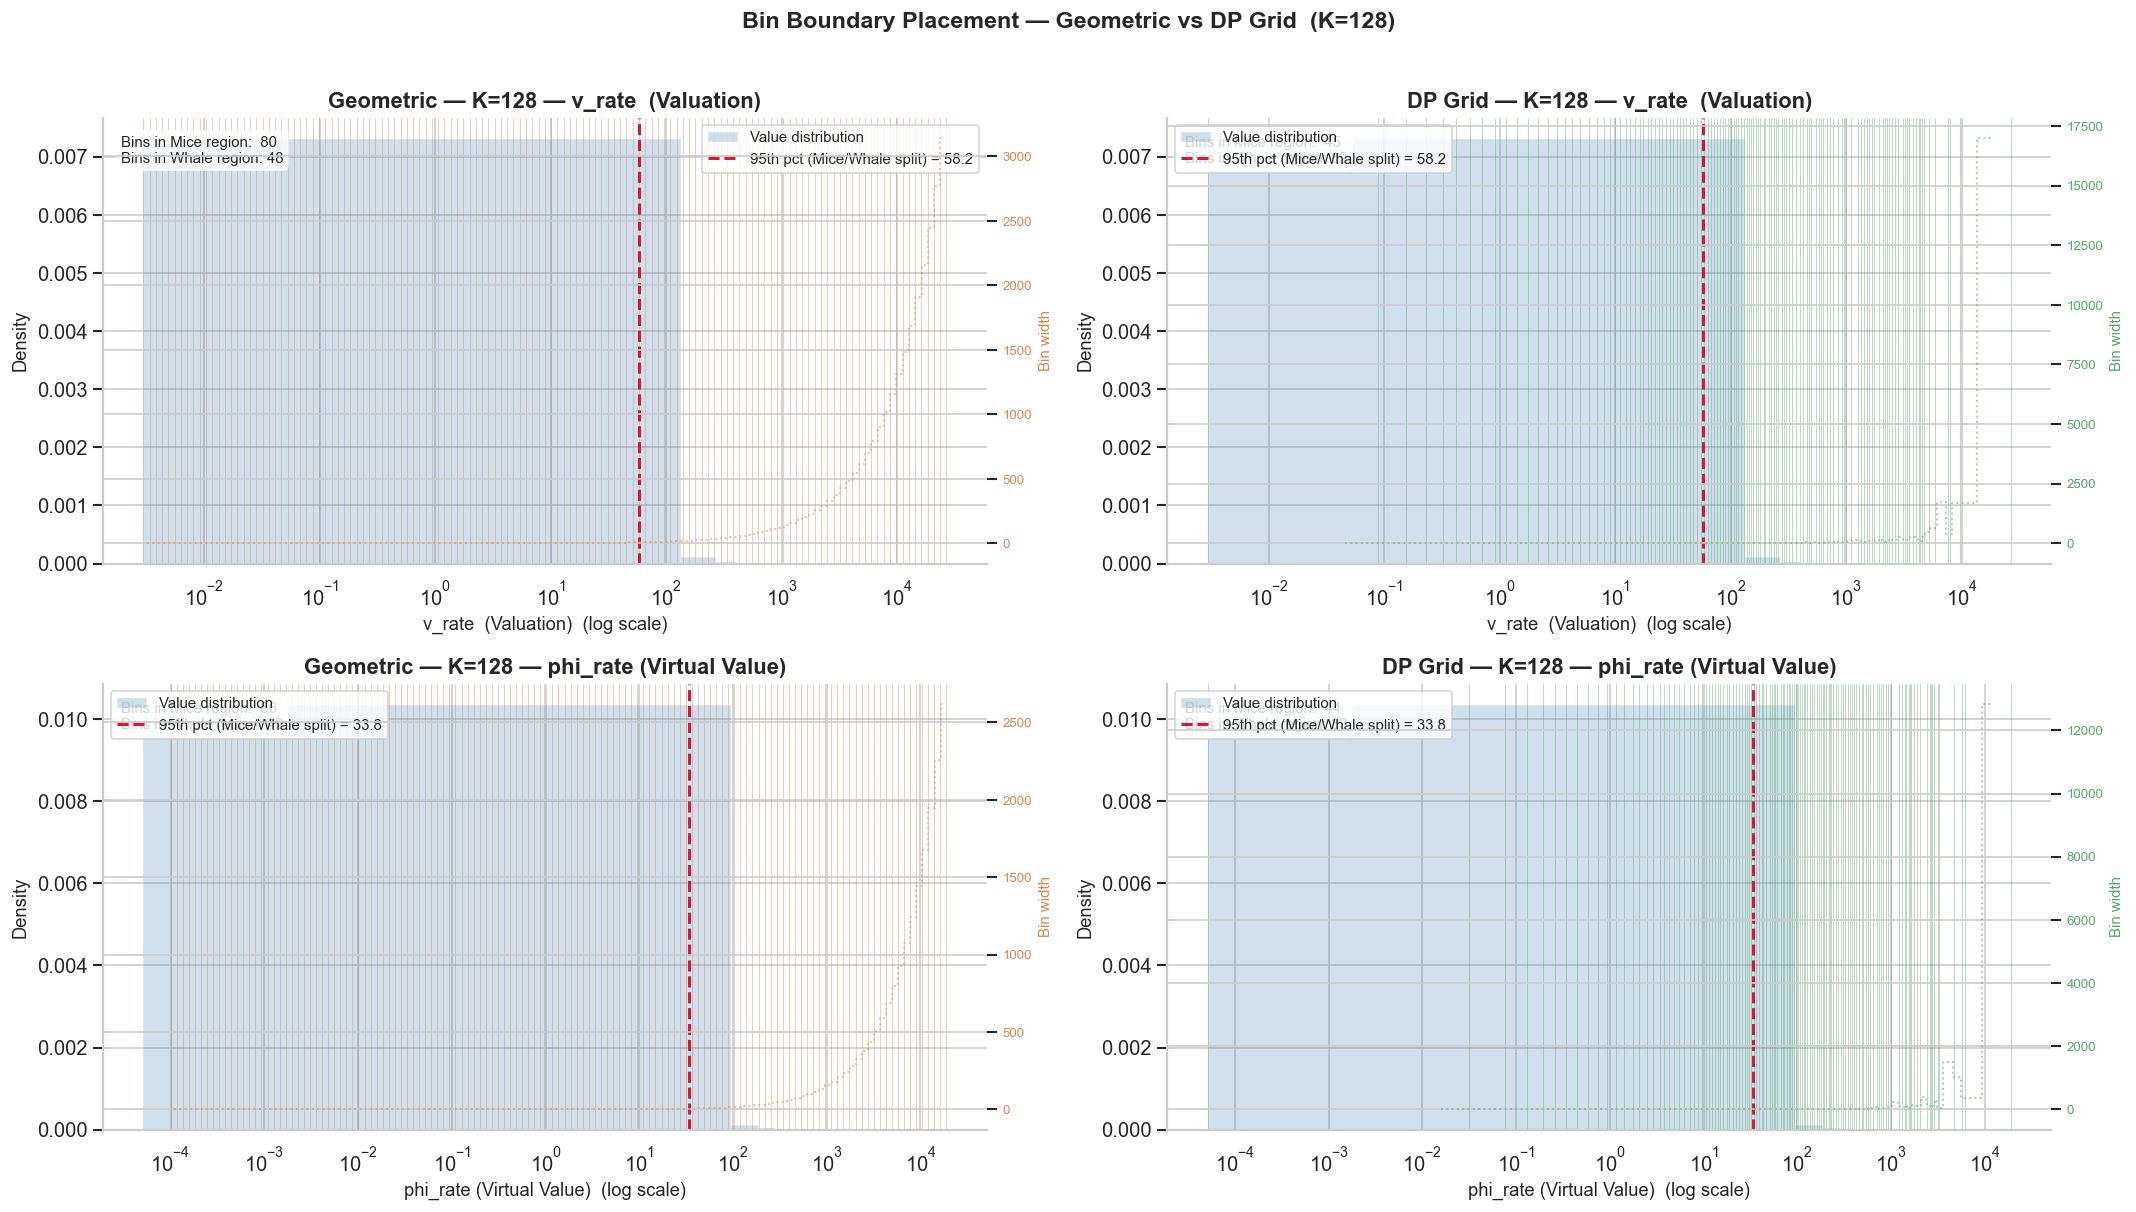

Saved → bin_boundaries_K128.pdf


In [16]:
# ── Bin Boundary Placement: Geometric vs DP Grid at K=128 ─────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use the full dataset (all phases combined) to fit boundaries
v_all   = df[V_COL].values.astype(float)
phi_all = df[PHI_COL].values.astype(float)

K_VIZ = 128

# ── Geometric edges (from full dataset range) ─────────────────────────────
def geo_edges(vals, K):
    valid = vals[vals > 0]
    return np.geomspace(max(valid.min(), 1e-4), valid.max(), K + 1)

edges_geo_v   = geo_edges(v_all,   K_VIZ)
edges_geo_phi = geo_edges(phi_all, K_VIZ)

# ── DP boundaries (fitted on full dataset) ────────────────────────────────
disc = Discretizer(K_bins=K_VIZ)
edges_dp_v   = disc.get_dp_boundaries(v_all)
edges_dp_phi = disc.get_dp_boundaries(phi_all)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row_idx, (vals, edges_geo, edges_dp, label) in enumerate([
    (v_all,   edges_geo_v,   edges_dp_v,   "v_rate  (Valuation)"),
    (phi_all, edges_geo_phi, edges_dp_phi, "phi_rate (Virtual Value)"),
]):
    positive = vals[vals > 0]

    for col_idx, (edges, method, color) in enumerate([
        (edges_geo, "Geometric", COLORS_GEO),
        (edges_dp,  "DP Grid",   COLORS_DP),
    ]):
        ax = axes[row_idx][col_idx]

        # Value distribution as log-scale histogram
        ax.hist(positive, bins=200, color='steelblue', alpha=0.25,
                density=True, label='Value distribution')

        # Bin boundaries as vertical lines
        for edge in edges:
            ax.axvline(edge, color=color, linewidth=0.4, alpha=0.6)

        # Mice / Whale threshold (95th percentile)
        p95 = np.percentile(positive, 95)
        ax.axvline(p95, color='crimson', linewidth=1.8,
                   linestyle='--', label=f'95th pct (Mice/Whale split) = {p95:.1f}')

        # Bin width profile: show widths as step plot on secondary axis
        ax2 = ax.twinx()
        widths = np.diff(edges)
        mids   = (edges[:-1] + edges[1:]) / 2
        ax2.step(mids, widths, where='mid', color=color,
                 alpha=0.5, linewidth=1.2, linestyle=':')
        ax2.set_ylabel('Bin width', fontsize=9, color=color)
        ax2.tick_params(axis='y', labelcolor=color, labelsize=8)

        ax.set_xscale('log')
        ax.set_xlabel(f'{label}  (log scale)', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'{method} — K={K_VIZ} — {label}', fontweight='bold')
        ax.legend(fontsize=9)

        # Annotate bin density in Mice vs Whale region
        n_mice_bins  = int(np.sum(edges[:-1] <  p95))
        n_whale_bins = int(np.sum(edges[:-1] >= p95))
        ax.text(0.02, 0.96,
                f'Bins in Mice region:  {n_mice_bins}\nBins in Whale region: {n_whale_bins}',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle(f'Bin Boundary Placement — Geometric vs DP Grid  (K={K_VIZ})',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('bin_boundaries_K128.pdf', bbox_inches='tight')
plt.show()
print('Saved → bin_boundaries_K128.pdf')

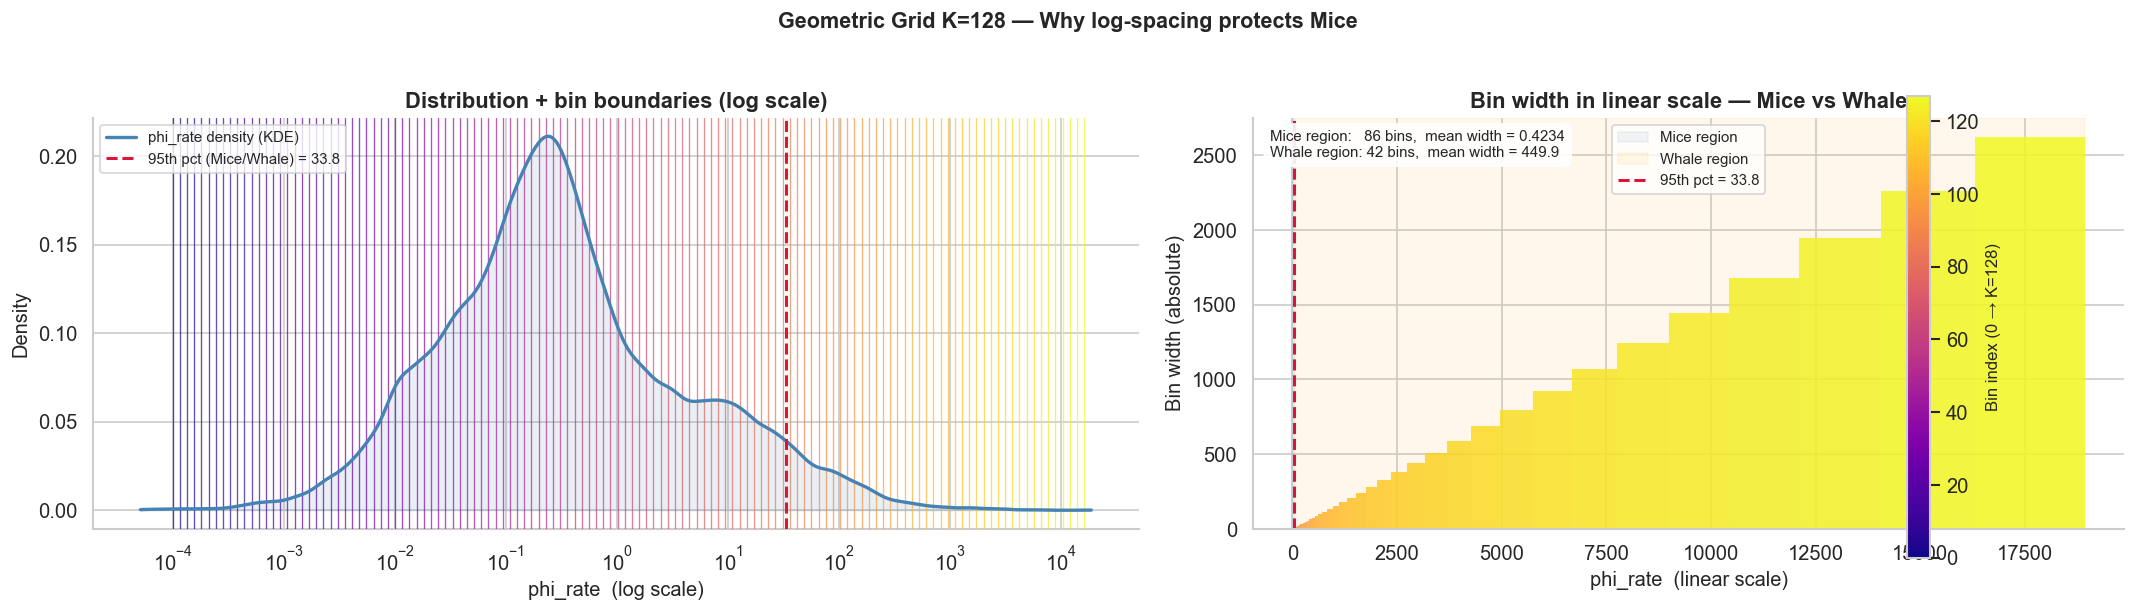

Mice  region: 86 bins, mean width = 0.4234
Whale region: 42 bins, mean width = 449.89
Ratio whale/mice bin width: 1063x


In [21]:
# ── Bin Boundary Placement: log + linear dual view ────────────────────────
from scipy.stats import gaussian_kde

phi_pos   = phi_all[phi_all > 0]
K_VIZ     = 128
edges_geo = geo_edges(phi_all, K_VIZ)
widths    = np.diff(edges_geo)
p95       = np.percentile(phi_pos, 95)

# KDE
log_vals = np.log10(phi_pos)
kde      = gaussian_kde(log_vals, bw_method=0.08)
x_log    = np.linspace(log_vals.min(), log_vals.max(), 2000)
x_lin    = 10 ** x_log
density  = kde(x_log) / np.log(10)

cmap  = plt.cm.plasma
norm  = plt.Normalize(vmin=0, vmax=K_VIZ - 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5),
                          gridspec_kw={'width_ratios': [1.2, 1]})

# ── LEFT: distribuzione su scala log ──────────────────────────────────────
ax = axes[0]
ax.plot(x_lin, density, color='steelblue', linewidth=2.0,
        label='phi_rate density (KDE)', zorder=5)
ax.fill_between(x_lin, density, alpha=0.12, color='steelblue')

for i, edge in enumerate(edges_geo[:-1]):
    ax.axvline(edge, color=cmap(norm(i)), linewidth=0.8, alpha=0.7, zorder=4)

ax.axvline(p95, color='crimson', linewidth=1.8, linestyle='--', zorder=6,
           label=f'95th pct (Mice/Whale) = {p95:.1f}')
ax.set_xscale('log')
ax.set_xlabel('phi_rate  (log scale)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution + bin boundaries (log scale)', fontweight='bold')
ax.legend(fontsize=9)

# ── RIGHT: larghezza assoluta dei bin su scala lineare ────────────────────
ax2 = axes[1]

# Shade Mice vs Whale regions
ax2.axvspan(edges_geo[0], p95,           alpha=0.08, color='steelblue', label='Mice region')
ax2.axvspan(p95,          edges_geo[-1], alpha=0.08, color='orange',    label='Whale region')

# Bar chart: ogni bin è una barra con altezza = larghezza assoluta
for i, (left, w) in enumerate(zip(edges_geo[:-1], widths)):
    ax2.bar(left, w, width=w, align='edge',
            color=cmap(norm(i)), alpha=0.85, edgecolor='none')

ax2.axvline(p95, color='crimson', linewidth=1.8, linestyle='--',
            label=f'95th pct = {p95:.1f}')

# Annotazioni quantitative
mice_bins  = np.sum(edges_geo[:-1] <  p95)
whale_bins = np.sum(edges_geo[:-1] >= p95)
mean_w_mice  = widths[edges_geo[:-1] <  p95].mean()
mean_w_whale = widths[edges_geo[:-1] >= p95].mean()

ax2.text(0.02, 0.97,
         f'Mice region:   {mice_bins} bins,  mean width = {mean_w_mice:.4f}\n'
         f'Whale region: {whale_bins} bins,  mean width = {mean_w_whale:.1f}',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))

ax2.set_xlabel('phi_rate  (linear scale)', fontsize=12)
ax2.set_ylabel('Bin width (absolute)', fontsize=12)
ax2.set_title('Bin width in linear scale — Mice vs Whale', fontweight='bold')
ax2.legend(fontsize=9)

# Colorbar condivisa
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.01, fraction=0.015)
cbar.set_label('Bin index (0 → K=128)', fontsize=10)

plt.suptitle(f'Geometric Grid K={K_VIZ} — Why log-spacing protects Mice',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('bin_boundaries_dual.pdf', bbox_inches='tight')
plt.show()

print(f'Mice  region: {mice_bins} bins, mean width = {mean_w_mice:.4f}')
print(f'Whale region: {whale_bins} bins, mean width = {mean_w_whale:.2f}')
print(f'Ratio whale/mice bin width: {mean_w_whale/mean_w_mice:.0f}x')

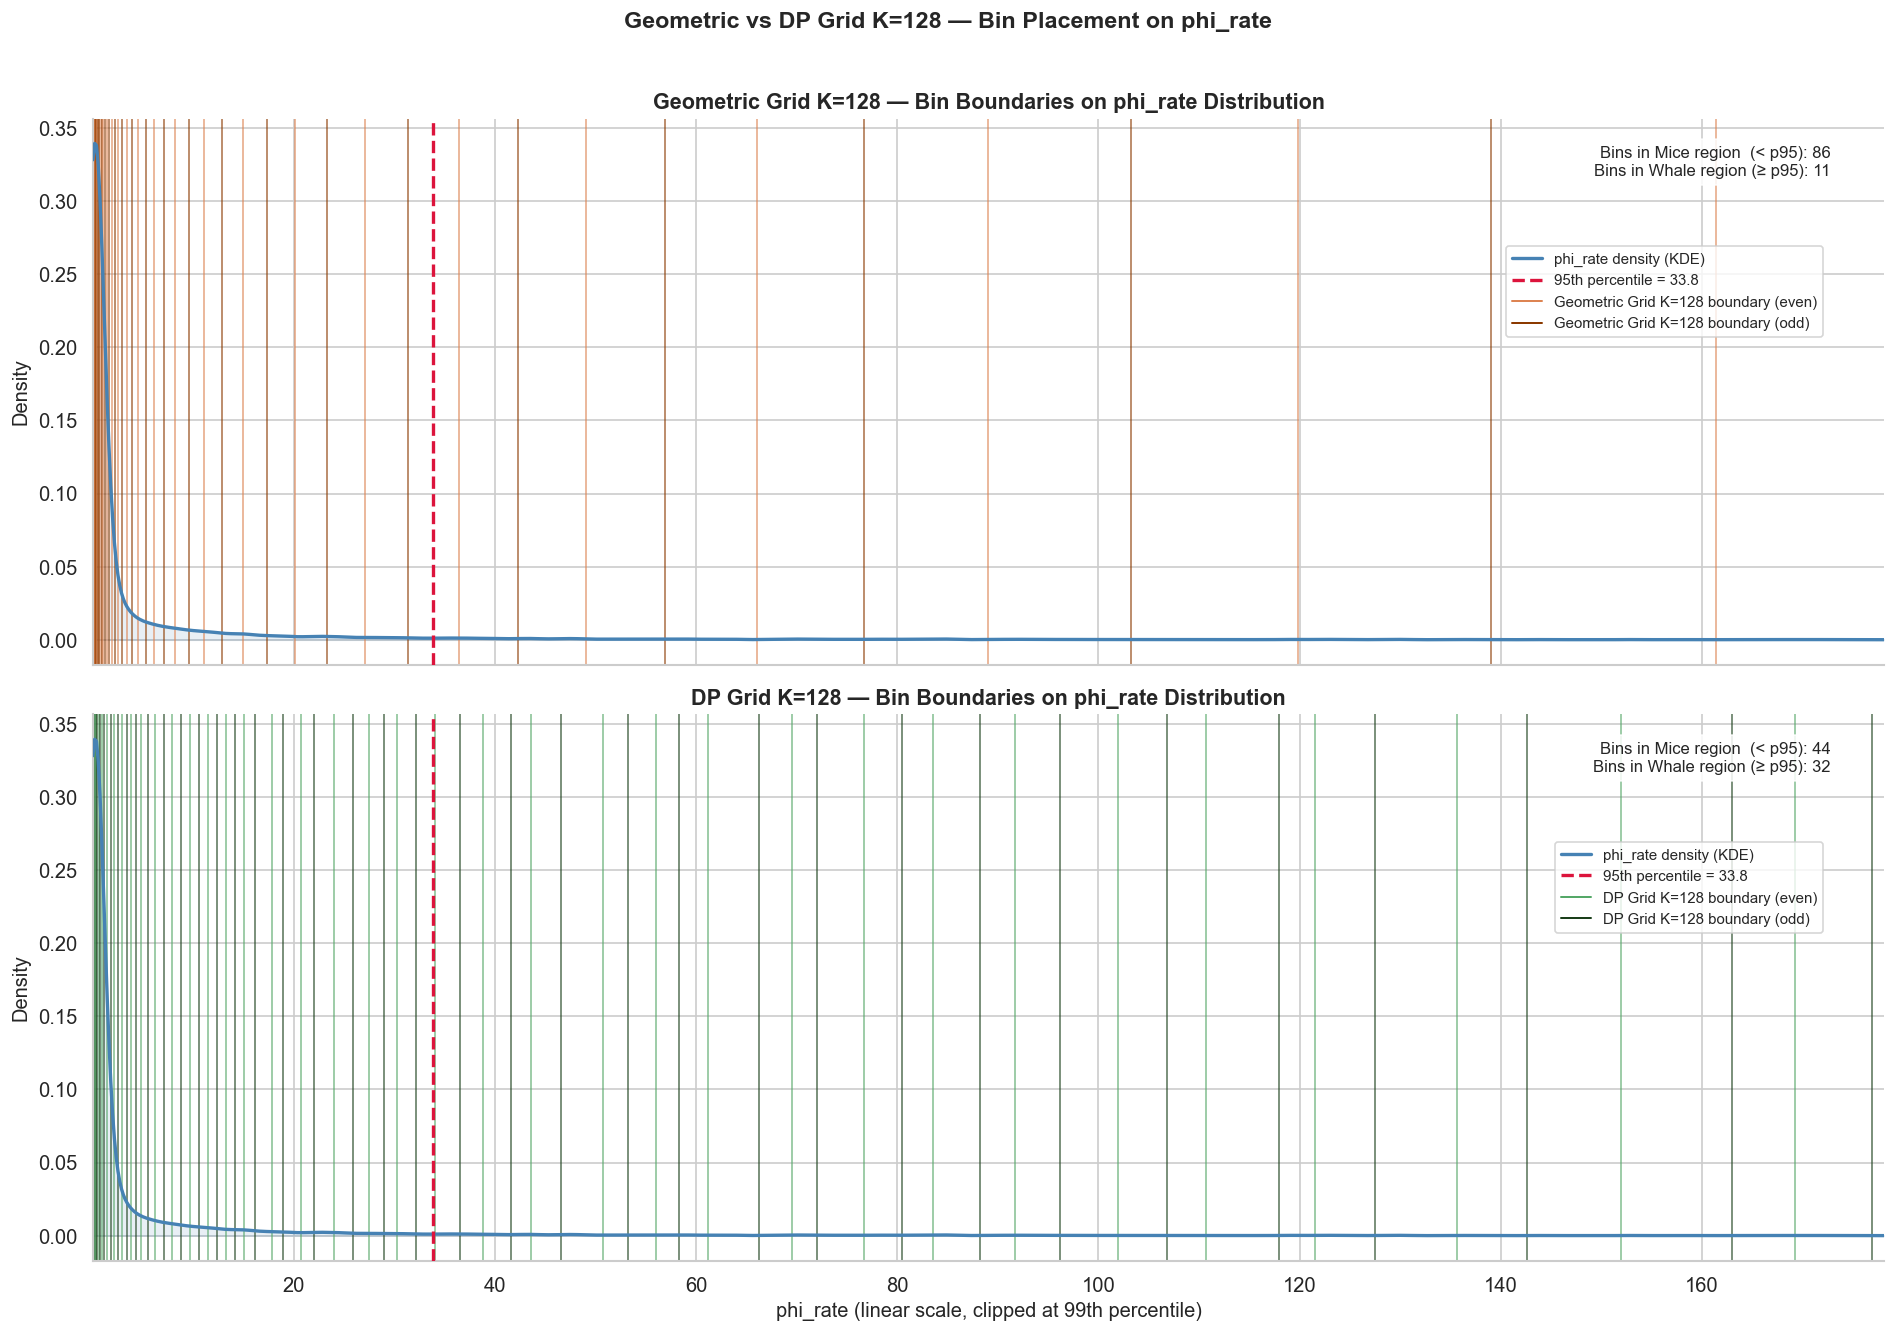

Geometric   : Mice bins=86  Whale bins=42  mean_width_mice=0.4234  mean_width_whale=449.89  ratio=1063x
DP Grid     : Mice bins=44  Whale bins=83  mean_width_mice=0.7743  mean_width_whale=227.68  ratio=294x


In [22]:
# ── Bin Boundary Placement: Geometric vs DP Grid K=128 on phi_rate ────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

phi_pos = phi_all[phi_all > 0]

# Edges
def geo_edges(vals, K):
    valid = vals[vals > 0]
    return np.geomspace(max(valid.min(), 1e-4), valid.max(), K + 1)

edges_geo = geo_edges(phi_all, 128)
disc128   = Discretizer(K_bins=128)
edges_dp  = disc128.get_dp_boundaries(phi_all)

# KDE clipped at p99
p95 = np.percentile(phi_pos, 95)
p99 = np.percentile(phi_pos, 99)
phi_clipped = phi_pos[phi_pos <= p99]
kde     = gaussian_kde(phi_clipped, bw_method=0.05)
x_grid  = np.linspace(phi_clipped.min(), p99, 1000)
density = kde(x_grid)

from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True, sharey=True)

for ax, edges, title, c1, c2 in [
    (axes[0], edges_geo, 'Geometric Grid K=128', COLORS_GEO,  '#8B3A00'),
    (axes[1], edges_dp,  'DP Grid K=128',        COLORS_DP,   '#1A3F1A'),
]:
    # KDE
    ax.plot(x_grid, density, color='steelblue', linewidth=2.0,
            zorder=3, label='phi_rate density (KDE)')
    ax.fill_between(x_grid, density, alpha=0.12, color='steelblue')

    # Boundaries clipped to visible range
    edges_vis = edges[edges <= p99]
    for i, edge in enumerate(edges_vis):
        ax.axvline(edge, color=c1 if i % 2 == 0 else c2,
                   linewidth=0.9, alpha=0.75, zorder=2)

    # Mice/Whale threshold
    ax.axvline(p95, color='crimson', linewidth=2.0,
               linestyle='--', zorder=4,
               label=f'95th percentile (Mice/Whale) = {p95:.1f}')

    # Annotations
    n_mice  = int(np.sum(edges[:-1] <  p95))
    n_whale = int(np.sum((edges[:-1] >= p95) & (edges[:-1] <= p99)))
    ax.text(0.97, 0.95,
            f'Bins in Mice region  (< p95): {n_mice}\n'
            f'Bins in Whale region (≥ p95): {n_whale}',
            transform=ax.transAxes, fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    legend_elements = [
        ax.get_lines()[0],
        Line2D([0],[0], color='crimson', linewidth=2, linestyle='--',
               label=f'95th percentile = {p95:.1f}'),
        Line2D([0],[0], color=c1, linewidth=1.2, label=f'{title} boundary (even)'),
        Line2D([0],[0], color=c2, linewidth=1.2, label=f'{title} boundary (odd)'),
    ]
    ax.legend(handles=legend_elements, fontsize=9,
              loc='upper right', bbox_to_anchor=(0.97, 0.78))
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{title} — Bin Boundaries on phi_rate Distribution',
                 fontweight='bold', fontsize=13)
    ax.set_xlim(phi_clipped.min(), p99)

axes[1].set_xlabel('phi_rate (linear scale, clipped at 99th percentile)', fontsize=12)

plt.suptitle('Geometric vs DP Grid K=128 — Bin Placement on phi_rate',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('bin_boundaries_geo_vs_dp_phi.pdf', bbox_inches='tight')
plt.show()

# Summary
for name, edges in [('Geometric', edges_geo), ('DP Grid', edges_dp)]:
    n_mice  = int(np.sum(edges[:-1] <  p95))
    n_whale = int(np.sum(edges[:-1] >= p95))
    widths  = np.diff(edges)
    mw_mice  = widths[edges[:-1] <  p95].mean()
    mw_whale = widths[edges[:-1] >= p95].mean()
    print(f'{name:<12}: Mice bins={n_mice}  Whale bins={n_whale}  '
          f'mean_width_mice={mw_mice:.4f}  mean_width_whale={mw_whale:.2f}  '
          f'ratio={mw_whale/mw_mice:.0f}x')